# Rabies 1D Spatial Diffusion — Traveling Wave

## Theory

Rabies in a fox population behaves as an SI epidemic: infected individuals
die from the disease, so there is no recovery (γ = 0).  When such an
epidemic is seeded in the centre of a 1D spatial chain of patches connected
by nearest-neighbour migration, it spreads outward as a **traveling wave**.

The theoretical wave speed for a diffusive SI model is:

$$c = 2\sqrt{D \cdot r}$$

where:
* D = r_migration × Δx² is the diffusion coefficient (with Δx = 1 node spacing),
* r = β − μ is the net per-capita growth rate of the infected class
  (≈ β when μ ≈ 0).

**Goal:** Build a 101-node chain, seed infection at node 50, run 200 ticks,
visualise the spatiotemporal I(t, x) heatmap, and compare the measured
wavefront speed to the theoretical prediction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap
from laser.cohorts import Model
from laser.cohorts.migration import Migration
from laser.cohorts.utils import static_routing
import laser.cohorts.SIR as SIR

In [2]:
# Model parameters
n_nodes    = 101
N_per_node = 1_000
I0         = 5        # infected individuals seeded at node 50 only
beta       = 0.3      # transmission rate (per day)
gamma      = 0.0      # no recovery — SI model (rabies is effectively SI)
r_migration = 0.05   # daily migration probability to each adjacent neighbour
nticks     = 200

# Theoretical wave speed: c = 2 * sqrt(D * r)
# D = r_migration * dx^2, dx = 1, r ≈ beta (SI, no death, no recovery)
D_diffusion   = r_migration * 1.0**2
r_growth      = beta
c_theory      = 2.0 * np.sqrt(D_diffusion * r_growth)

print(f"n_nodes    = {n_nodes}")
print(f"r_migration = {r_migration}")
print(f"beta       = {beta}")
print(f"D          = {D_diffusion:.4f}")
print(f"c_theory   = {c_theory:.4f} nodes/tick")

n_nodes    = 101
r_migration = 0.05
beta       = 0.3
D          = 0.0500
c_theory   = 0.2449 nodes/tick


In [3]:
# Build a tri-diagonal nearest-neighbour routing matrix
# Each row i lists the fractional flow FROM node i TO each other node.
# Interior nodes share equally with left and right neighbours.
# Endpoint nodes have only one neighbour, so all migration goes there.
routing_2d = np.zeros((n_nodes, n_nodes), dtype=np.float64)
for i in range(n_nodes):
    if i > 0:
        routing_2d[i, i - 1] = 1.0
    if i < n_nodes - 1:
        routing_2d[i, i + 1] = 1.0

routing_3d = static_routing(routing_2d, nticks)

print(f"routing_2d shape: {routing_2d.shape}")
print(f"routing_3d shape: {routing_3d.shape}")
print(f"Row 0 (left endpoint):  {routing_2d[0, :4]}")
print(f"Row 50 (centre):        {routing_2d[50, 48:53]}")
print(f"Row 100 (right endpt):  {routing_2d[100, 97:]}")

routing_2d shape: (101, 101)
routing_3d shape: (200, 101, 101)
Row 0 (left endpoint):  [0. 1. 0. 0.]
Row 50 (centre):        [0. 1. 0. 1. 0.]
Row 100 (right endpt):  [0. 0. 1. 0.]


In [4]:
# Build scenario: all nodes fully susceptible, except node 50
scenario = grid(M=n_nodes, N=1)
scenario["S"] = N_per_node
scenario["I"] = 0
scenario.loc[50, "S"] = N_per_node - I0
scenario.loc[50, "I"] = I0

print(f"Scenario rows: {len(scenario)}")
print(f"Seed node 50:  S={scenario.loc[50, 'S']}, I={scenario.loc[50, 'I']}")

Scenario rows: 101
Seed node 50:  S=995, I=5


In [5]:
# Build SI model with nearest-neighbour migration
# No vital dynamics, no recovery (gamma=0) — pure SI
params = PropertySet({"nticks": nticks})
model  = Model(scenario, params)

betas        = ValuesMap.from_scalar(beta,  nticks, n_nodes)
r_recoveries = ValuesMap.from_scalar(gamma, nticks, n_nodes)

model.components = [
    SIR.Susceptible(model),
    SIR.Infectious(model, r_recovery=r_recoveries),
    SIR.Recovered(model),
    Migration(model, r_migration=r_migration, routing=routing_3d),
    SIR.Transmission(model, beta=betas),
]

model.run()
print("Simulation complete.")
print(f"I array shape: {model.states.I.shape}   (nticks+1, nnodes)")

Simulation complete.
I array shape: (201, 101)   (nticks+1, nnodes)


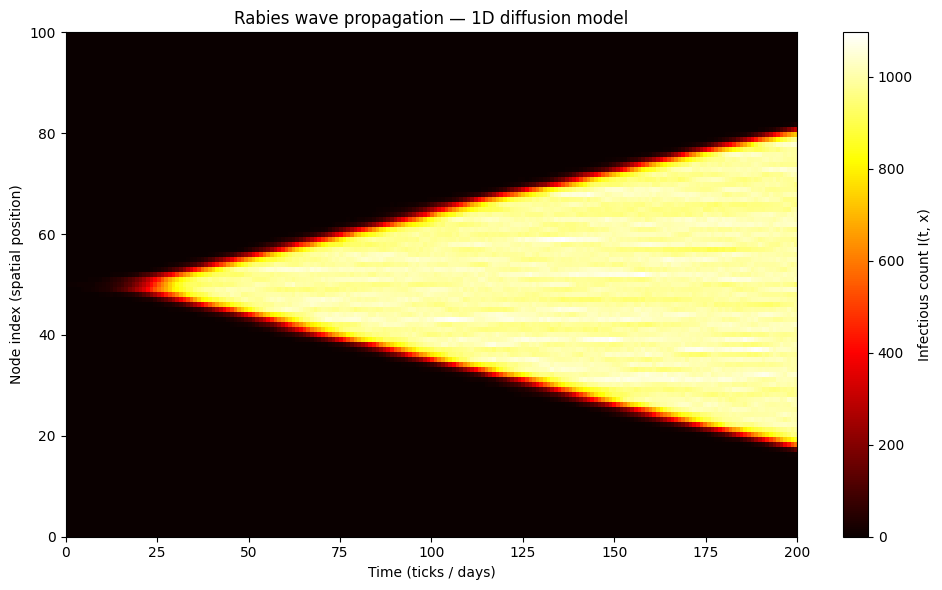

In [6]:
# Spatiotemporal heatmap of I(t, x)
# Transpose to (nnodes, nticks+1) for imshow where y-axis = node, x-axis = time
I_matrix = model.states.I.T   # shape: (n_nodes, nticks+1)

fig, ax = plt.subplots(figsize=(10, 6))
img = ax.imshow(
    I_matrix,
    aspect="auto",
    origin="lower",
    extent=[0, nticks, 0, n_nodes - 1],
    cmap="hot",
)
plt.colorbar(img, ax=ax, label="Infectious count I(t, x)")
ax.set_xlabel("Time (ticks / days)")
ax.set_ylabel("Node index (spatial position)")
ax.set_title("Rabies wave propagation — 1D diffusion model")
plt.tight_layout()
plt.show()

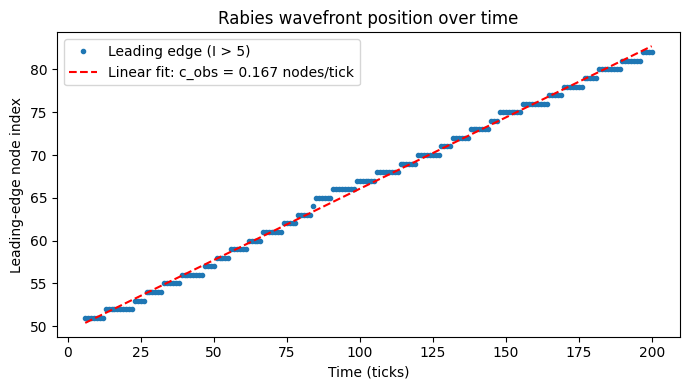

Theoretical wave speed : c = 2√(D·β)  = 0.2449 nodes/tick
Observed wave speed    :               = 0.1667 nodes/tick
Ratio (obs/theory)     :               = 0.680


In [7]:
# Estimate observed wavespeed from the leading-edge position over time
# Define the leading edge as the rightmost node (> node 50) with I > 5
threshold = 5
leading_edge = []
times        = []

for t in range(nticks + 1):
    # Nodes to the right of the seed (index > 50)
    right_half = model.states.I[t, 51:]
    infected_nodes = np.where(right_half > threshold)[0]
    if len(infected_nodes) > 0:
        leading_edge.append(51 + infected_nodes[-1])  # rightmost node above threshold
        times.append(t)

if len(times) > 10:
    # Linear fit to the leading-edge position vs. time
    times_arr   = np.array(times)
    edge_arr    = np.array(leading_edge)
    fit_coeffs  = np.polyfit(times_arr, edge_arr, 1)
    c_observed  = fit_coeffs[0]   # slope = nodes per tick

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(times_arr, edge_arr, "o", ms=3, label="Leading edge (I > 5)")
    ax.plot(times_arr, np.polyval(fit_coeffs, times_arr),
            "r--", label=f"Linear fit: c_obs = {c_observed:.3f} nodes/tick")

    ax.set_xlabel("Time (ticks)")
    ax.set_ylabel("Leading-edge node index")
    ax.set_title("Rabies wavefront position over time")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Theoretical wave speed : c = 2√(D·β)  = {c_theory:.4f} nodes/tick")
    print(f"Observed wave speed    :               = {c_observed:.4f} nodes/tick")
    print(f"Ratio (obs/theory)     :               = {c_observed/c_theory:.3f}")
else:
    print("Wave has not spread enough to estimate speed — increase nticks.")